# Fermeture $w_{sec}\partial_z\bar u$ du flux de Reynolds — correction $\theta/T$, extension verticale, cadre bulk-plume (Romps 2014)
## Méso-NH RCE `large300`

Notebook indépendant. Reprend le setup commun et refait, dans l'ordre, tous les calculs du notebook précédent (sans les réafficher un par un), pour arriver directement à la comparaison finale 2–8 km. La suite répond point par point aux questions posées sur papier : correction $\theta/T$ de l'équilibre radiatif-subsident, extension au-dessus de 8 km et abandon en dessous de 1.5–2 km, comparaison $\theta_c$ (nuage) vs $\bar\theta$ (environnement) via un diagnostic d'entraînement à la Romps (2014), test des hypothèses H1/H2 sur le bilan de moment en flux de masse, et une métrique de comparaison dépendante de $z$ plus informative qu'une simple corrélation globale.

## §0. Setup commun (identique aux notebooks précédents)

In [31]:
# ============================================================
#  SETUP COMMUN
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import gc, os
from scipy.ndimage import uniform_filter1d

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.grid':True,
                     'grid.alpha':0.25,'image.cmap':'RdBu_r'})
Rd,Rv=287.05,461.5; EPSILON=Rd/Rv; g=9.81; cp=1004.0; p_ref=1e5
Z_TOP_KM=15.0
DIR_3D,DIR_2D,DIR_1D='3D','2D','1D'
def path3d(v): return os.path.join(DIR_3D,f'MESONH_RCE_large300_3D_{v}.nc')
def path2d(v): return os.path.join(DIR_2D,f'MESONH_RCE_large300_2D_{v}.nc')
def path1d(v): return os.path.join(DIR_1D,f'MESONH_RCE_large300_1D_{v}.nc')
BLOC=2

_ds=xr.open_dataset(path3d('ua')); _da=_ds['ua']
dim_t,dim_z,dim_y,dim_x=_da.dims[:4]
n_t,n_z=_da.sizes[dim_t],_da.sizes[dim_z]; n_y,n_x=_da.sizes[dim_y],_da.sizes[dim_x]
_ds.close(); del _ds,_da; gc.collect()
_ds1=xr.open_dataset(path1d('ua_avg')); alt=_ds1.altitude.values.astype(float).copy(); _ds1.close()
zkm=alt/1000.0
mask_show=alt<=Z_TOP_KM*1000; m28=(alt>=2000)&(alt<=8000); m812=(alt>=8000)&(alt<=12000)
m015=(alt>=0)&(alt<=2000)

t_stat=0; idx_stat=slice(t_stat,None); n_stat=n_t-t_stat
dt_phys=6*3600.0
tt=np.arange(n_stat)

ds_prw=xr.open_dataset(path2d('prw')); prw_all=ds_prw['prw'].load(); ds_prw.close()
prw_mean=prw_all.isel({dim_t:idx_stat}).mean(dim=dim_t)
PRW_SEUIL=float(np.median(prw_all.values.ravel()))
mh=(prw_mean.values>PRW_SEUIL); ms=~mh; mh_flat=mh.ravel(); ms_flat=ms.ravel()
f_h=float(mh.mean()); f_s=float(ms.mean())
del prw_all; gc.collect()

def smooth_t(fld, win=8):
    return uniform_filter1d(fld, size=win, axis=1, mode='nearest')

print(f'{n_t}t x {n_z}z x {n_y}y x {n_x}x | humide={f_h:.0%} sec={f_s:.0%}')


100t x 74z x 128y x 2000x | humide=43% sec=57%


## §1. Recalcul groupé des champs du notebook précédent (silencieux)

In [32]:
# ============================================================
#  rho0(z), theta(z,t), T(z,t)  — domaine total
# ============================================================
rho0_sum=np.zeros(n_z); n_rho=0
theta_zt=np.zeros((n_z,n_stat)); T_zt=np.zeros((n_z,n_stat))
ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa')); ds_hus=xr.open_dataset(path3d('hus'))
for t0 in range(t_stat,n_t,BLOC):
    t1=min(t0+BLOC,n_t); sl={dim_t:slice(t0,t1)}
    T=ds_ta['ta'].isel(sl).values; p=ds_pa['pa'].isel(sl).values; qv=ds_hus['hus'].isel(sl).values
    Tv=T*(1+qv/EPSILON)/(1+qv); rho=p/(Rd*Tv)
    rho0_sum+=rho.mean(axis=(0,2,3))*(t1-t0); n_rho+=(t1-t0)
    del T,p,qv,Tv,rho; gc.collect()
ds_ta.close(); ds_pa.close(); ds_hus.close(); rho0=rho0_sum/n_rho

ds_ta=xr.open_dataset(path3d('ta')); ds_pa=xr.open_dataset(path3d('pa'))
for iz in range(n_z):
    T=ds_ta['ta'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    p=ds_pa['pa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    theta=T*(p_ref/p)**(Rd/cp)
    theta_zt[iz]=theta.mean(axis=1); T_zt[iz]=T.mean(axis=1)
    del T,p,theta
ds_ta.close(); ds_pa.close(); gc.collect()
dthetadz_zt=np.gradient(theta_zt, alt, axis=0)
print('rho0, theta_zt, T_zt, dthetadz_zt : ok')


rho0, theta_zt, T_zt, dthetadz_zt : ok


In [33]:
# ============================================================
#  ubar_zt, wbar_zt, flux_zt (u'w') — domaine total
#  + u_h_zt/u_s_zt, w_h_zt/w_s_zt — decomposition humide/sec
# ============================================================
ubar_zt=np.zeros((n_z,n_stat)); wbar_zt=np.zeros((n_z,n_stat)); flux_zt=np.zeros((n_z,n_stat))
u_h_zt=np.zeros((n_z,n_stat)); u_s_zt=np.zeros((n_z,n_stat))
w_h_zt=np.zeros((n_z,n_stat)); w_s_zt=np.zeros((n_z,n_stat))
ds_u=xr.open_dataset(path3d('ua')); ds_w=xr.open_dataset(path3d('wa'))
for iz in range(n_z):
    u=ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    w=ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    ub=u.mean(axis=1); wb=w.mean(axis=1); up=u-ub[:,None]; wp=w-wb[:,None]
    ubar_zt[iz]=ub; wbar_zt[iz]=wb; flux_zt[iz]=rho0[iz]*(up*wp).mean(axis=1)
    u_h_zt[iz]=u[:,mh_flat].mean(axis=1); u_s_zt[iz]=u[:,ms_flat].mean(axis=1)
    w_h_zt[iz]=w[:,mh_flat].mean(axis=1); w_s_zt[iz]=w[:,ms_flat].mean(axis=1)
    del u,w,ub,wb,up,wp; gc.collect()
ds_u.close(); ds_w.close(); gc.collect()

dudz_tot=np.gradient(ubar_zt, alt, axis=0)
uw_zt=flux_zt/rho0[:,None]
terme_flux=smooth_t(-(1/rho0[:,None])*np.gradient(flux_zt, alt, axis=0))
dudz_tot_s=smooth_t(dudz_tot); w_s_obs_s=smooth_t(w_s_zt)
print('ubar_zt, wbar_zt, flux_zt, u_h/s_zt, w_h/s_zt, terme_flux : ok')


ubar_zt, wbar_zt, flux_zt, u_h/s_zt, w_h/s_zt, terme_flux : ok


In [34]:
# ============================================================
#  tntr(z,t) domaine total — tendance radiative
# ============================================================
tntr_zt=np.zeros((n_z,n_stat))
ds_tntr=xr.open_dataset(path3d('tntr'))
for iz in range(n_z):
    tr=ds_tntr['tntr'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    tntr_zt[iz]=tr.mean(axis=1)
    del tr
ds_tntr.close(); gc.collect()

with np.errstate(divide='ignore', invalid='ignore'):
    w_sec_rce_brut     = -tntr_zt/dthetadz_zt                      # sans correction theta/T
    w_sec_rce_corrige  = -(theta_zt/T_zt)*tntr_zt/dthetadz_zt      # avec correction theta/T (H0)
w_sec_rce_brut_s    = smooth_t(w_sec_rce_brut)
w_sec_rce_corrige_s = smooth_t(w_sec_rce_corrige)
w_sec_rce_x_shear    = smooth_t(w_sec_rce_corrige*dudz_tot)
print('tntr_zt, w_sec_rce (brut+corrige), fermeture finale : ok')


tntr_zt, w_sec_rce (brut+corrige), fermeture finale : ok


## §2. Affichage final — fermeture complète sur 2–8 km

/tmp/ipykernel_37639/1514850730.py:8: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m28], fld[m28], cmap='RdBu_r',


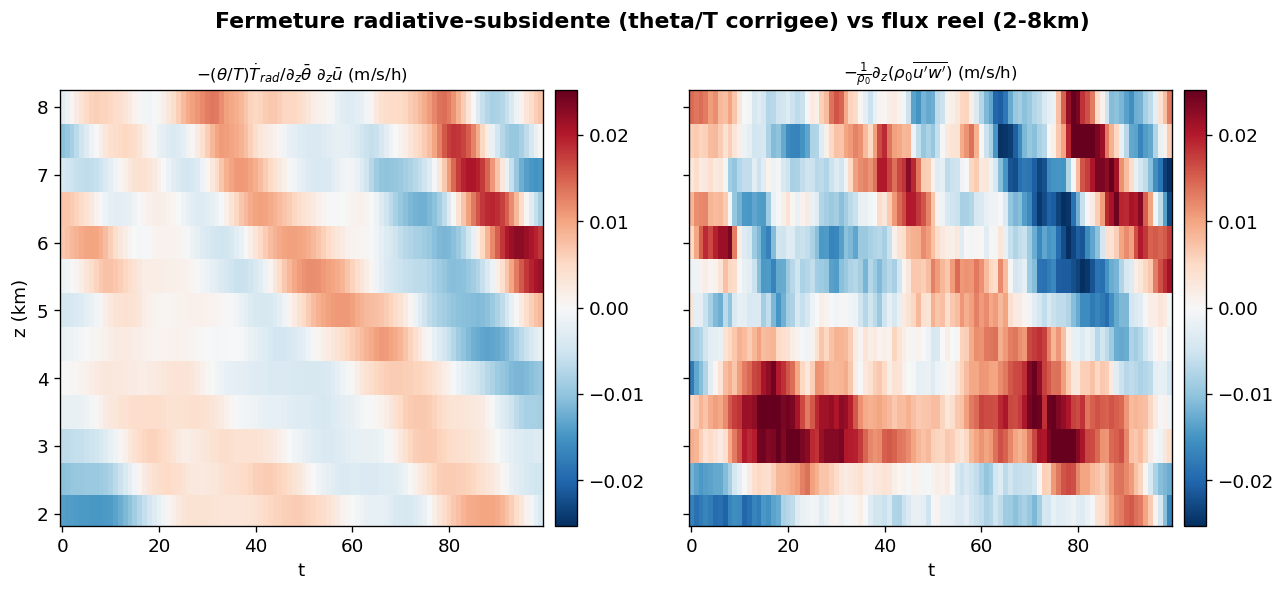

In [58]:
# ============================================================
#  terme_flux vs w_sec_rce_corrige * dudz_tot, 2-8km
# ============================================================
fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.percentile(np.abs(terme_flux[m28]),98), np.percentile(np.abs(w_sec_rce_x_shear[m28]),98))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(w_sec_rce_x_shear*3600, r"$-(\theta/T)\dot T_{rad}/\partial_z\bar\theta\ \partial_z\bar u$ (m/s/h)"),
                                (terme_flux*3600, r"$-\frac{1}{\rho_0}\partial_z(\rho_0\overline{u'w'})$ (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m28], fld[m28], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle('Fermeture radiative-subsidente (theta/T corrigee) vs flux reel (2-8km)', fontweight='bold')
plt.tight_layout(); plt.show()



## §3. La correction $\theta/T$ améliore-t-elle vraiment l'ajustement ? (H0 du tableau)

$$w_{sec}\,\partial_z\bar\theta = \frac{\theta}{T}\dot T_{rad} \quad\text{(H0, tableau)}$$

On compare $w_{sec}$ observé (zone sèche) à sa version prédite **sans** le facteur $\theta/T$ (ce que le premier essai avait fait par erreur) et **avec** ce facteur — le facteur croit avec l'altitude, donc l'écart entre les deux versions doit se creuser en montant.

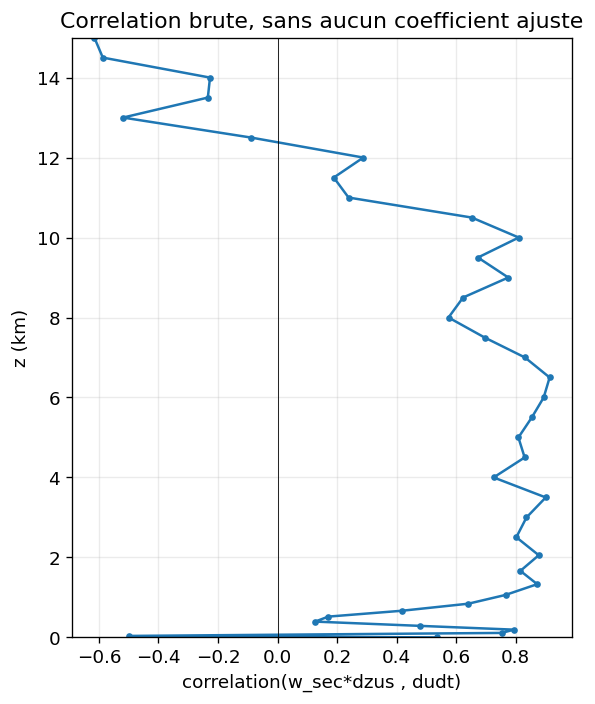

In [37]:
# ============================================================
#  Comparaison SANS regression : correlation brute, niveau par niveau
# ============================================================
r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = w_sec_rce_x_shear[iz,:],terme_flux[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
 
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation(w_sec*dzus , dudt)'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title("Correlation brute, sans aucun coefficient ajuste")
plt.tight_layout(); plt.show()


## §5. $\theta_c$ (nuage) vs $\bar\theta$ (environnement) — diagnostic d'entraînement à la Romps (2014)



In [60]:
# ============================================================
#  theta_c = theta restreinte a la zone humide (meme construction que theta_zt, masque mh)
# ============================================================
theta_c_zt = np.zeros((n_z, n_stat))
ds_ta = xr.open_dataset(path3d('ta')); ds_pa = xr.open_dataset(path3d('pa'))
for iz in range(n_z):
    T = ds_ta['ta'].isel({dim_t:idx_stat, dim_z:iz}).values.reshape(n_stat,-1)
    p = ds_pa['pa'].isel({dim_t:idx_stat, dim_z:iz}).values.reshape(n_stat,-1)
    theta = T*(p_ref/p)**(Rd/cp)
    theta_c_zt[iz] = theta[:,mh_flat].mean(axis=1)   # moyenne sur les colonnes humides uniquement
    del T,p,theta
ds_ta.close(); ds_pa.close(); gc.collect()

14226

In [61]:
dtheta_c_dz_zt = np.gradient(theta_c_zt, alt, axis=0)
duc_dz_zt = np.gradient(u_h_zt, alt, axis=0)
denom_u_zt = ubar_zt - u_h_zt

In [62]:

w_sec_rce_corrige_2  = -(theta_c_zt/T_zt)*tntr_zt/dtheta_c_dz_zt
dudt_pred_zt =  w_sec_rce_corrige_2*dudz_tot

In [63]:
dudt_tot_raw = np.gradient(ubar_zt, dt_phys, axis=1)
dudt_tot = smooth_t(dudt_tot_raw)


/tmp/ipykernel_37639/417204437.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_tot[mask_show], cmap='RdBu_r', shading='auto')
/tmp/ipykernel_37639/417204437.py:11: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_pred_zt[mask_show]*3600, cmap='RdBu_r',


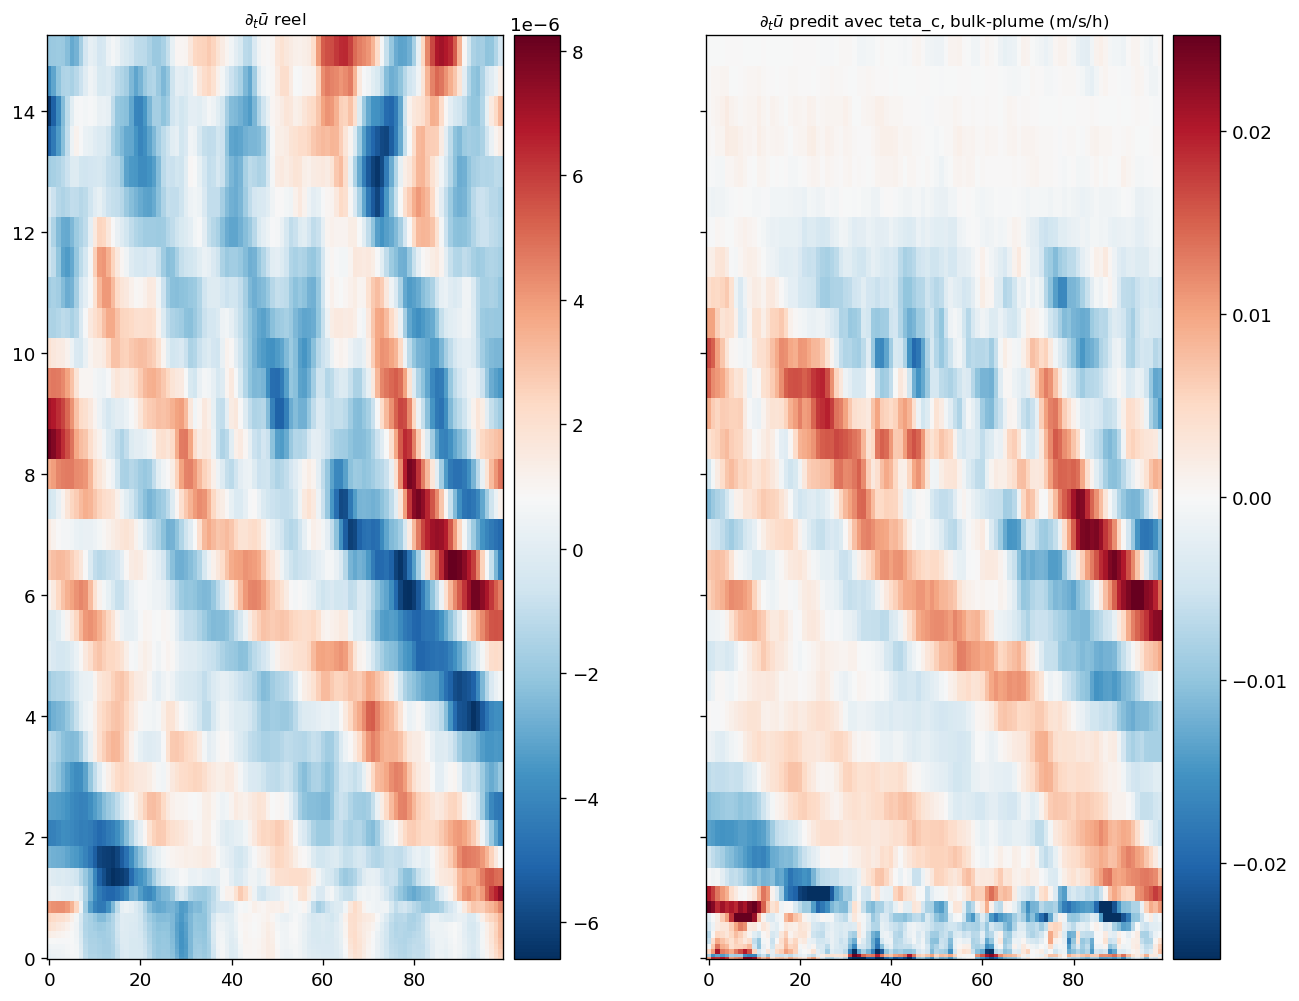

In [64]:
# ============================================================
#  Affichage : theta_c, epsilon, D, dudt_pred — chacun en (z,t)
# ============================================================
fig, axes = plt.subplots(1,2,figsize=(13,10),sharex=True,sharey=True)

ax = axes[0]
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_tot[mask_show], cmap='RdBu_r', shading='auto')
ax.set_title(r'$\partial_t\bar u$ reel', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

ax = axes[1]
im = ax.pcolormesh(tt+t_stat, zkm[mask_show], dudt_pred_zt[mask_show]*3600, cmap='RdBu_r',
                    norm=TwoSlopeNorm(0,-v,v), shading='auto')
ax.set_title(r'$\partial_t\bar u$ predit avec teta_c, bulk-plume (m/s/h)', fontsize=10); fig.colorbar(im,ax=ax,pad=.02)

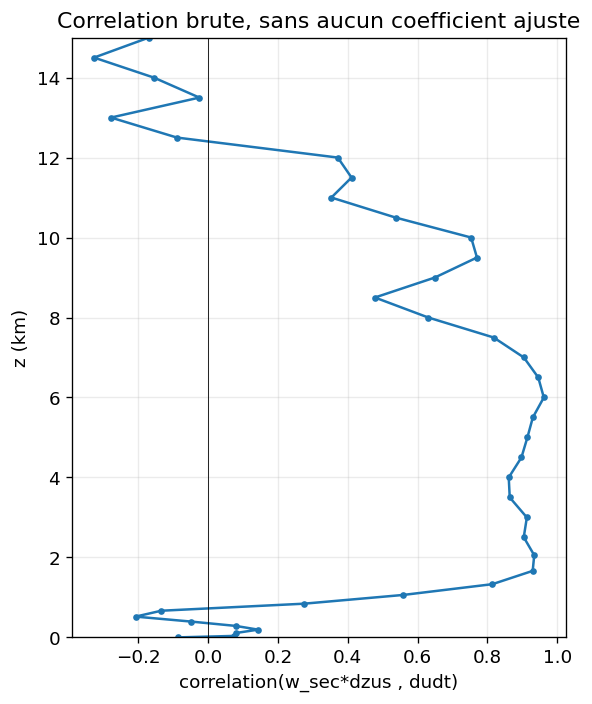

In [46]:
# ============================================================
#  Comparaison SANS regression : correlation brute, niveau par niveau
# ============================================================
r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = dudt_tot[iz,:],dudt_pred_zt[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
 
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation(w_sec*dzus , dudt)'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title("Correlation brute, sans aucun coefficient ajuste")
plt.tight_layout(); plt.show()


## §6. Bilan en flux de masse (tableau blanc) — test des hypothèses H1 et H2


$$T_u = -w_{sec}\,\partial_z\bar u + detraînement $$

Voir calcul preuve.

fraction de points (z,t) valides sur 2-12km avec N_MIN_POINTS=200 : 100%


/tmp/ipykernel_37639/2269088755.py:67: RuntimeWarning: All-NaN slice encountered
  D_z_composite = np.nanmedian(D_zt, axis=1)


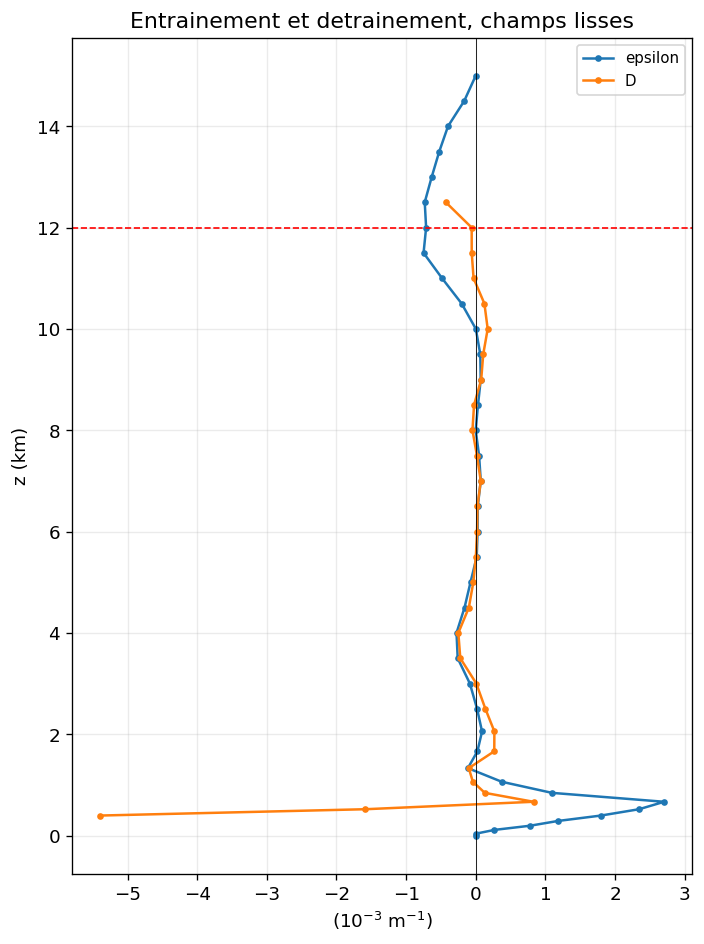

/tmp/ipykernel_37639/2269088755.py:86: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',


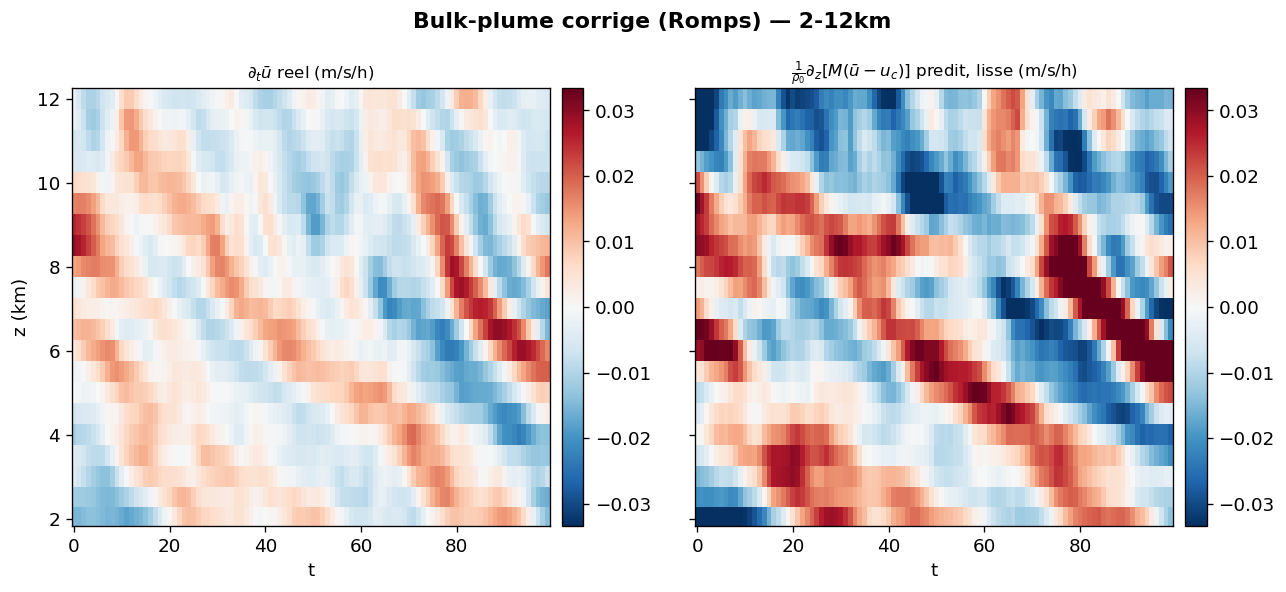

In [93]:
# AAAAAAAAAAAAAAAAAAAAAA============================================================
#  Bulk-plume a la Romps (2014), corrige pour bien modeliser jusqu'a 12km
#  1) M(z,t), u_c(z,t) avec seuil d'echantillon renforce
#  2) lissage vertical (comblement + moyenne glissante), comme le fit
#     quadratique que Romps applique a epsilon avant de l'utiliser
#  3) epsilon(z,t), D(z,t) sur les champs lisses
#  4) test direct de l'equation testable (eq.2/15) jusqu'a 12km
# ============================================================
from scipy.ndimage import uniform_filter1d

SEUIL_W = 1e-5; SEUIL_COND = 1e-5
N_MIN_POINTS = 200
m212 = (alt>=2000)&(alt<=12000)

# ---- 1) M et u_c, masque nuage + seuil d'echantillon ----
M_zt = np.full((n_z, n_stat), np.nan)
uc_zt = np.full((n_z, n_stat), np.nan)
f_cloud_zt = np.zeros((n_z, n_stat))

ds_u = xr.open_dataset(path3d('ua')); ds_w = xr.open_dataset(path3d('wa'))
ds_clw = xr.open_dataset(path3d('clw')); ds_cli = xr.open_dataset(path3d('cli'))
for iz in range(n_z):
    u = ds_u['ua'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    w = ds_w['wa'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    clw = ds_clw['clw'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    cli = ds_cli['cli'].isel({dim_t:idx_stat,dim_z:iz}).values.reshape(n_stat,-1)
    cloud = (w > SEUIL_W) & ((clw+cli) > SEUIL_COND)
    for it in range(n_stat):
        m = cloud[it,:]; f_cloud_zt[iz,it] = m.mean()
        if m.sum() >= N_MIN_POINTS:
            w_m = w[it,m]; u_m = u[it,m]
            M_zt[iz,it] = rho0[iz] * f_cloud_zt[iz,it] * w_m.mean()
            uc_zt[iz,it] = np.sum(w_m*u_m)/np.sum(w_m)
    del u,w,clw,cli,cloud
ds_u.close(); ds_w.close(); ds_clw.close(); ds_cli.close(); gc.collect()

frac_valide = np.mean(np.isfinite(uc_zt[m212]))
print(f"fraction de points (z,t) valides sur 2-12km avec N_MIN_POINTS={N_MIN_POINTS} : {frac_valide:.0%}")

# ---- 2) comblement + lissage vertical de M et u_c ----
def combler_et_lisser(champ_zt, fallback_zt, win=5):
    out = champ_zt.copy()
    for it in range(n_stat):
        col = out[:,it]
        valid = np.isfinite(col)
        if valid.sum() < 3:
            out[:,it] = fallback_zt[:,it]; continue
        out[:,it] = np.interp(alt, alt[valid], col[valid])
    return uniform_filter1d(out, size=win, axis=0, mode='nearest')

M_zt_lisse  = combler_et_lisser(M_zt,  np.zeros_like(M_zt))
uc_zt_lisse = combler_et_lisser(uc_zt, ubar_zt)

# ---- 3) epsilon(z,t) et D(z,t) sur champs lisses ----
duc_dz_zt = np.gradient(uc_zt_lisse, alt, axis=0)
denom_zt = ubar_zt - uc_zt_lisse
echelle = np.nanpercentile(np.abs(denom_zt[m212]), 90)
with np.errstate(divide='ignore', invalid='ignore'):
    eps_zt = np.where(np.abs(denom_zt) > 0.3*echelle, duc_dz_zt/denom_zt, np.nan)

dMdz_zt = np.gradient(M_zt_lisse, alt, axis=0)
echelle_M = np.nanpercentile(np.abs(M_zt_lisse[m212]), 90)
with np.errstate(divide='ignore', invalid='ignore'):
    D_zt = np.where(np.abs(M_zt_lisse) > 0.3*echelle_M, eps_zt - dMdz_zt/M_zt_lisse, np.nan)

eps_z_composite = np.nanmedian(eps_zt, axis=1)
D_z_composite = np.nanmedian(D_zt, axis=1)

fig, ax = plt.subplots(figsize=(6,8))
ax.plot(eps_z_composite[mask_show]*1e3, zkm[mask_show], 'o-', ms=3, label='epsilon')
ax.plot(D_z_composite[mask_show]*1e3, zkm[mask_show], 'o-', ms=3, label='D')
ax.axhline(12, color='r', lw=1, ls='--'); ax.axvline(0,color='k',lw=.5); ax.legend(fontsize=9)
ax.set_xlabel(r'($10^{-3}$ m$^{-1}$)'); ax.set_ylabel('z (km)')
ax.set_title("Entrainement et detrainement, champs lisses")
plt.tight_layout(); plt.show()

# ---- 4) test direct de l'equation testable, jusqu'a 12km ----
dudt_pred = (1/rho0[:,None]) * np.gradient(M_zt_lisse*(ubar_zt - uc_zt_lisse), alt, axis=0)
dudt_pred_s = smooth_t(dudt_pred)
dudt_reel = smooth_t(np.gradient(ubar_zt, dt_phys, axis=1))

fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m212]),95), np.nanpercentile(np.abs(dudt_pred_s[m212]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ predit, lisse (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m212], fld[m212], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Bulk-plume corrige (Romps) — 2-12km", fontweight='bold')
plt.tight_layout(); plt.show()

NaN dans M_zt  : 4132 / 7400 (55.8%)
NaN dans uc_zt : 4132 / 7400 (55.8%)


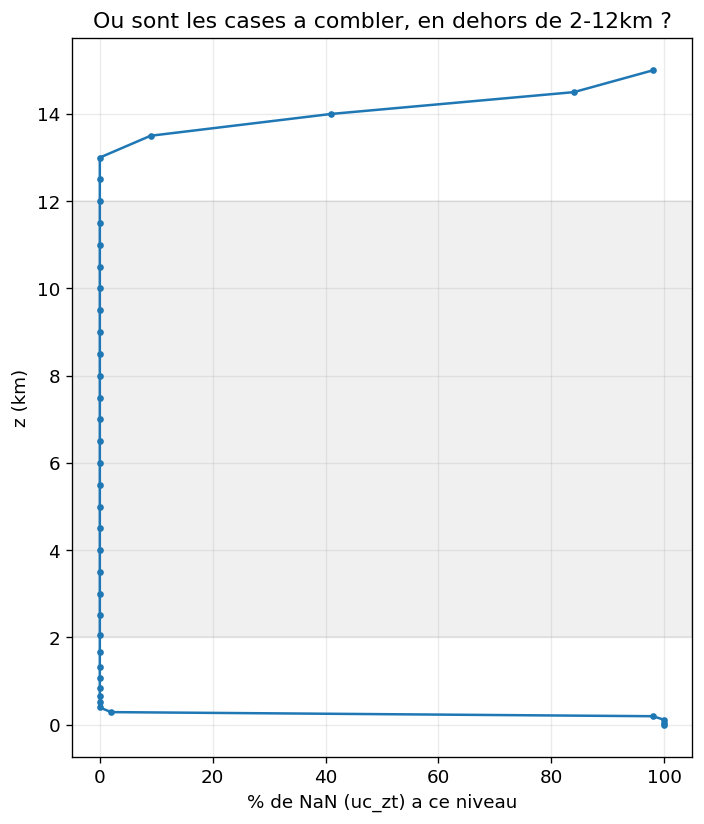

NaN dans la bande 2-12km uniquement : 0.00% (devrait etre ~0)
NaN en dehors de 2-12km              : 78.0%


In [94]:
# ============================================================
#  Diagnostic : y a-t-il vraiment des NaN a combler, et ou (dans quelle bande d'altitude) ?
# ============================================================
nan_M = ~np.isfinite(M_zt)
nan_uc = ~np.isfinite(uc_zt)

print(f"NaN dans M_zt  : {nan_M.sum()} / {M_zt.size} ({nan_M.mean()*100:.1f}%)")
print(f"NaN dans uc_zt : {nan_uc.sum()} / {uc_zt.size} ({nan_uc.mean()*100:.1f}%)")

# repartition par niveau : combien de NaN a chaque altitude (sur tous les instants)
nan_par_niveau = nan_uc.mean(axis=1)*100
fig, ax = plt.subplots(figsize=(6,7))
ax.plot(nan_par_niveau[mask_show], zkm[mask_show], 'o-', ms=3)
ax.axhspan(2,12,color='k',alpha=.06)
ax.set_xlabel('% de NaN (uc_zt) a ce niveau'); ax.set_ylabel('z (km)')
ax.set_title('Ou sont les cases a combler, en dehors de 2-12km ?')
plt.tight_layout(); plt.show()

print(f"NaN dans la bande 2-12km uniquement : {nan_uc[m212].mean()*100:.2f}% (devrait etre ~0)")
print(f"NaN en dehors de 2-12km              : {nan_uc[~m212].mean()*100:.1f}%")

In [95]:
f_cloud_zt[iz,it] = m.mean()   # m = cloud, le masque booleen w>seuil ET condensat>seuil
print(f"fraction nuageuse moyenne (2-8km) : {np.nanmean(f_cloud_zt[m28])*100:.1f}%")

fraction nuageuse moyenne (2-8km) : 1.5%


In [96]:
print(f"R2 median 2-8km  : {np.nanmedian(R2_romps[m28]):.2f}")
print(f"R2 median 8-12km : {np.nanmedian(R2_romps[(alt>=8000)&(alt<=10000)]):.2f}")

R2 median 2-8km  : -0.23
R2 median 8-12km : -0.84


/tmp/ipykernel_37639/3824901592.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m810], fld[m810], cmap='RdBu_r',


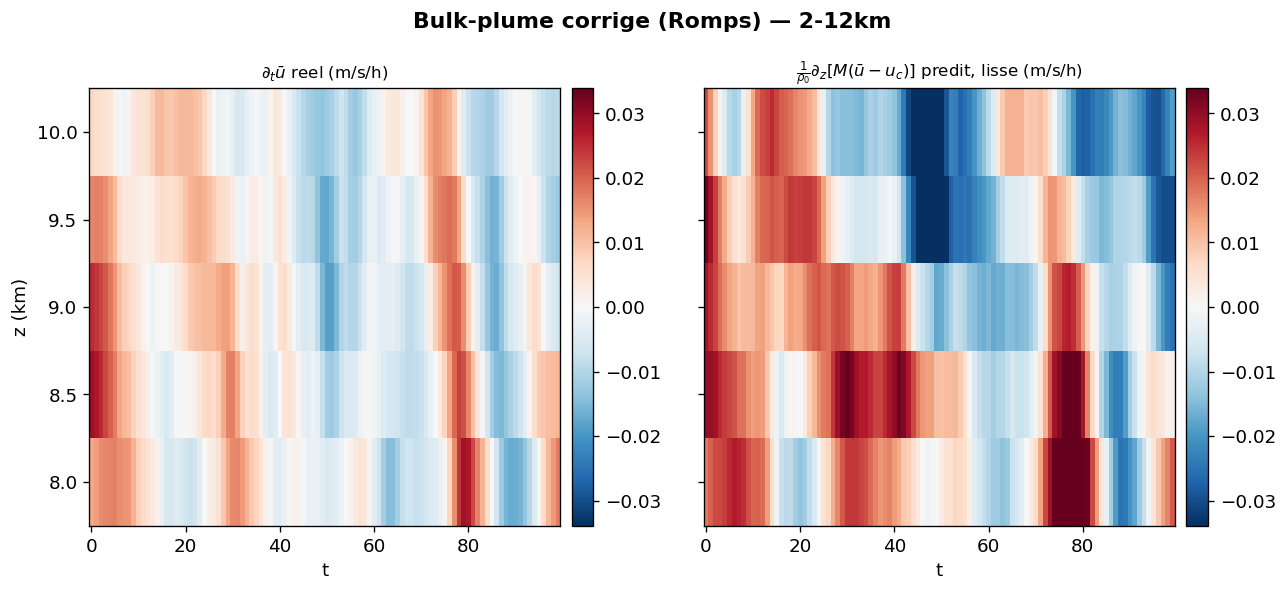

In [97]:
m810 = (alt>=8000)&(alt<=10000)
fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m810]),95), np.nanpercentile(np.abs(dudt_pred_s[m810]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ predit, lisse (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m810], fld[m810], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Bulk-plume corrige (Romps) — 2-12km", fontweight='bold')
plt.tight_layout(); plt.show()

/tmp/ipykernel_37639/949025123.py:6: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m812], fld[m812], cmap='RdBu_r',


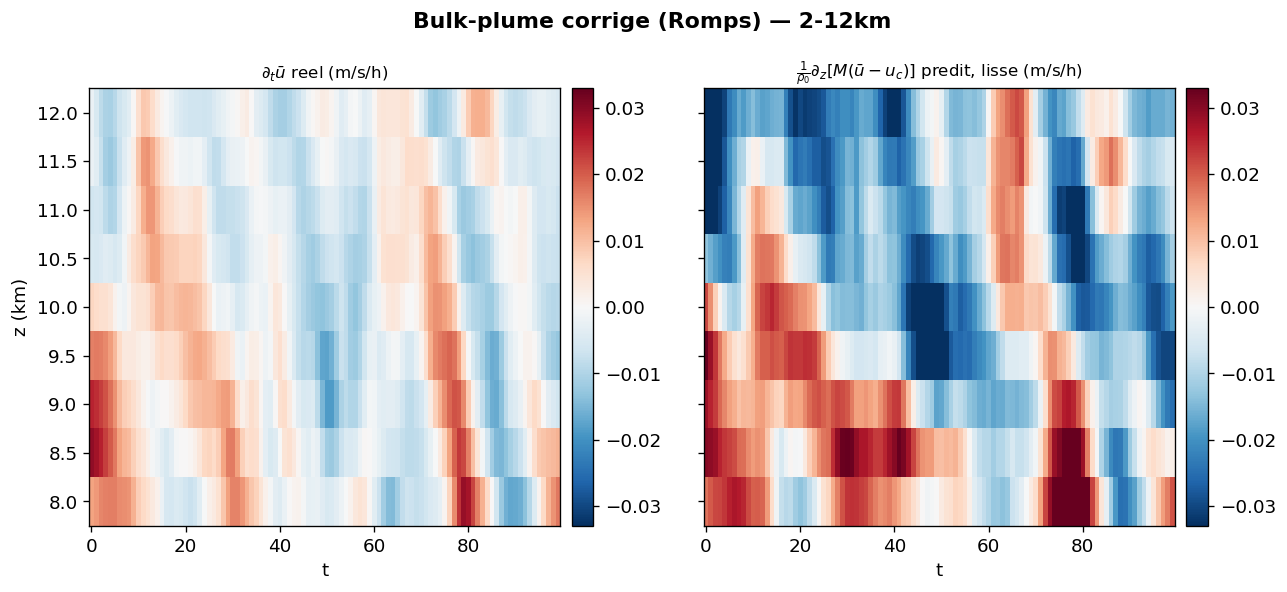

In [102]:
m812 = (alt>=8000)&(alt<=12000)
fig, axes = plt.subplots(1,2,figsize=(11,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m812]),95), np.nanpercentile(np.abs(dudt_pred_s[m812]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ predit, lisse (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m812], fld[m812], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("Bulk-plume corrige (Romps) — 2-12km", fontweight='bold')
plt.tight_layout(); plt.show()

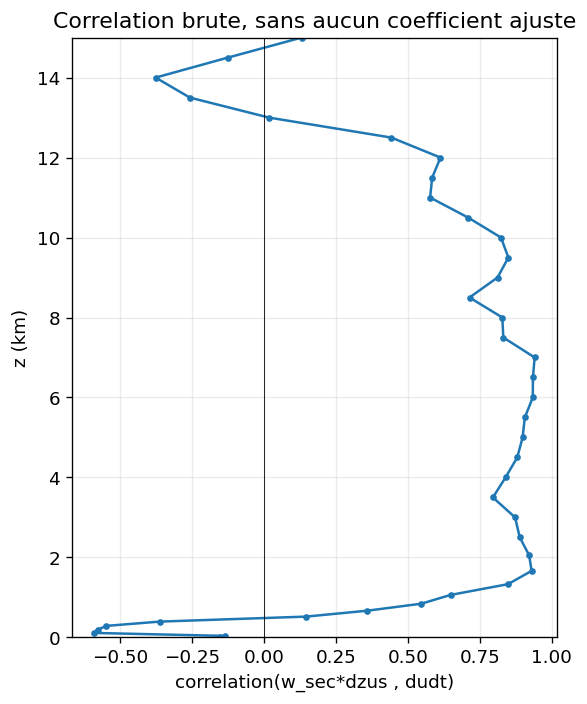

In [98]:
# ============================================================
#  Comparaison SANS regression : correlation brute, niveau par niveau
# ============================================================
r_brut = np.full(n_z, np.nan)
for iz in range(n_z):
    x, y = dudt_reel[iz,:],dudt_pred_s[iz,:]
    if np.nanstd(x) < 1e-15 or np.nanstd(y) < 1e-15: continue
    r_brut[iz] = np.corrcoef(x,y)[0,1]
 
fig, ax = plt.subplots(figsize=(5,6))
ax.plot(r_brut[mask_show], zkm[mask_show], 'o-', ms=3); ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('correlation(w_sec*dzus , dudt)'); ax.set_ylabel('z (km)'); ax.set_ylim(0,Z_TOP_KM)
ax.set_title("Correlation brute, sans aucun coefficient ajuste")
plt.tight_layout(); plt.show()


In [99]:
# ============================================================
#  Diagnostic direct : biais, variance, et R2 recalcule proprement
# ============================================================
for iz in range(n_z):
    if not (8000<=alt[iz]<=12000): continue
    a, b = dudt_reel[iz,:], dudt_pred_s[iz,:]
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 20: continue
    biais = np.mean(b[ok]-a[ok])
    std_a = np.std(a[ok]); std_b = np.std(b[ok])
    corr = np.corrcoef(a[ok], b[ok])[0,1]
    print(f"z={zkm[iz]:.1f}km | n_valid={ok.sum()} | biais={biais*3600:+.4f} | "
          f"std_reel={std_a*3600:.4f} | std_pred={std_b*3600:.4f} | corr={corr:+.2f}")

z=8.0km | n_valid=100 | biais=+0.0065 | std_reel=0.0103 | std_pred=0.0164 | corr=+0.83
z=8.5km | n_valid=100 | biais=+0.0083 | std_reel=0.0099 | std_pred=0.0156 | corr=+0.71
z=9.0km | n_valid=100 | biais=+0.0024 | std_reel=0.0099 | std_pred=0.0148 | corr=+0.81
z=9.5km | n_valid=100 | biais=-0.0046 | std_reel=0.0092 | std_pred=0.0184 | corr=+0.85
z=10.0km | n_valid=100 | biais=-0.0085 | std_reel=0.0076 | std_pred=0.0176 | corr=+0.82
z=10.5km | n_valid=100 | biais=-0.0099 | std_reel=0.0072 | std_pred=0.0140 | corr=+0.71
z=11.0km | n_valid=100 | biais=-0.0089 | std_reel=0.0064 | std_pred=0.0137 | corr=+0.58
z=11.5km | n_valid=100 | biais=-0.0080 | std_reel=0.0055 | std_pred=0.0148 | corr=+0.58
z=12.0km | n_valid=100 | biais=-0.0119 | std_reel=0.0058 | std_pred=0.0145 | corr=+0.61


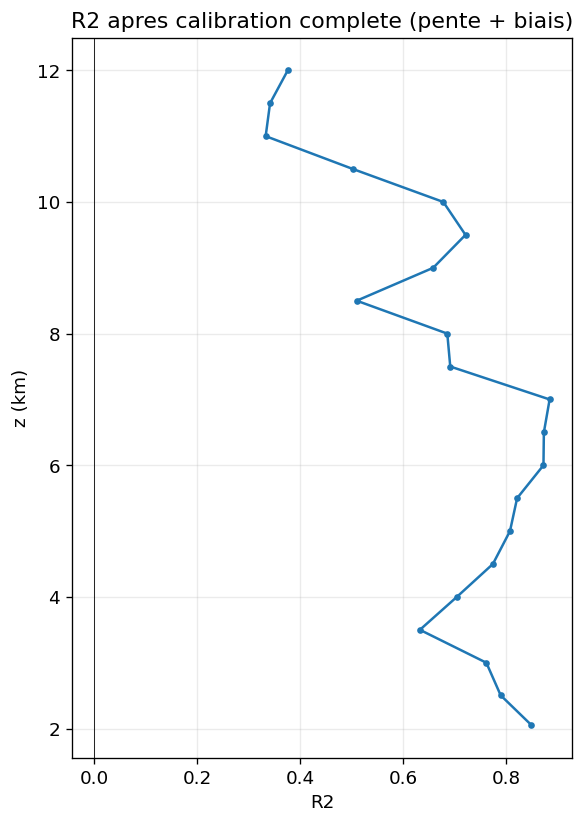

R2 median 2-8km  : 0.7890720030217393
R2 median 8-12km : 0.5094890863178386


In [100]:
# ============================================================
#  Recalibration complete (pente + biais) par niveau, sur 2-12km
# ============================================================
pente_z = np.full(n_z, np.nan); biais_z = np.full(n_z, np.nan)
for iz in range(n_z):
    if not m212[iz]: continue
    a, b = dudt_reel[iz,:], dudt_pred_s[iz,:]
    ok = np.isfinite(a) & np.isfinite(b)
    if ok.sum() < 20 or np.std(b[ok]) < 1e-15: continue
    A = np.vstack([b[ok], np.ones(ok.sum())]).T
    coefs, *_ = np.linalg.lstsq(A, a[ok], rcond=None)   # a = pente*b + biais
    pente_z[iz], biais_z[iz] = coefs

dudt_pred_calibre = pente_z[:,None]*dudt_pred_s + biais_z[:,None]

R2_calibre = np.full(n_z, np.nan)
for iz in range(n_z):
    if not m212[iz]: continue
    a, b = dudt_reel[iz,:], dudt_pred_calibre[iz,:]
    if np.nanstd(a) < 1e-15 or np.all(np.isnan(b)): continue
    ss_res = np.nansum((a-b)**2); ss_tot = np.nansum((a-a.mean())**2)
    R2_calibre[iz] = 1-ss_res/ss_tot if ss_tot>0 else np.nan

fig, ax = plt.subplots(figsize=(5,7))
ax.plot(R2_calibre[m212], zkm[m212], 'o-', ms=3)
ax.axvline(0,color='k',lw=.5)
ax.set_xlabel('R2'); ax.set_ylabel('z (km)')
ax.set_title('R2 apres calibration complete (pente + biais)')
plt.tight_layout(); plt.show()
print('R2 median 2-8km  :', np.nanmedian(R2_calibre[m28]))
print('R2 median 8-12km :', np.nanmedian(R2_calibre[(alt>=8000)&(alt<=12000)]))

/tmp/ipykernel_37639/1330256592.py:17: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im=ax.pcolormesh(tt+t_stat, zkm[m112], fld[m112], cmap='RdBu_r',


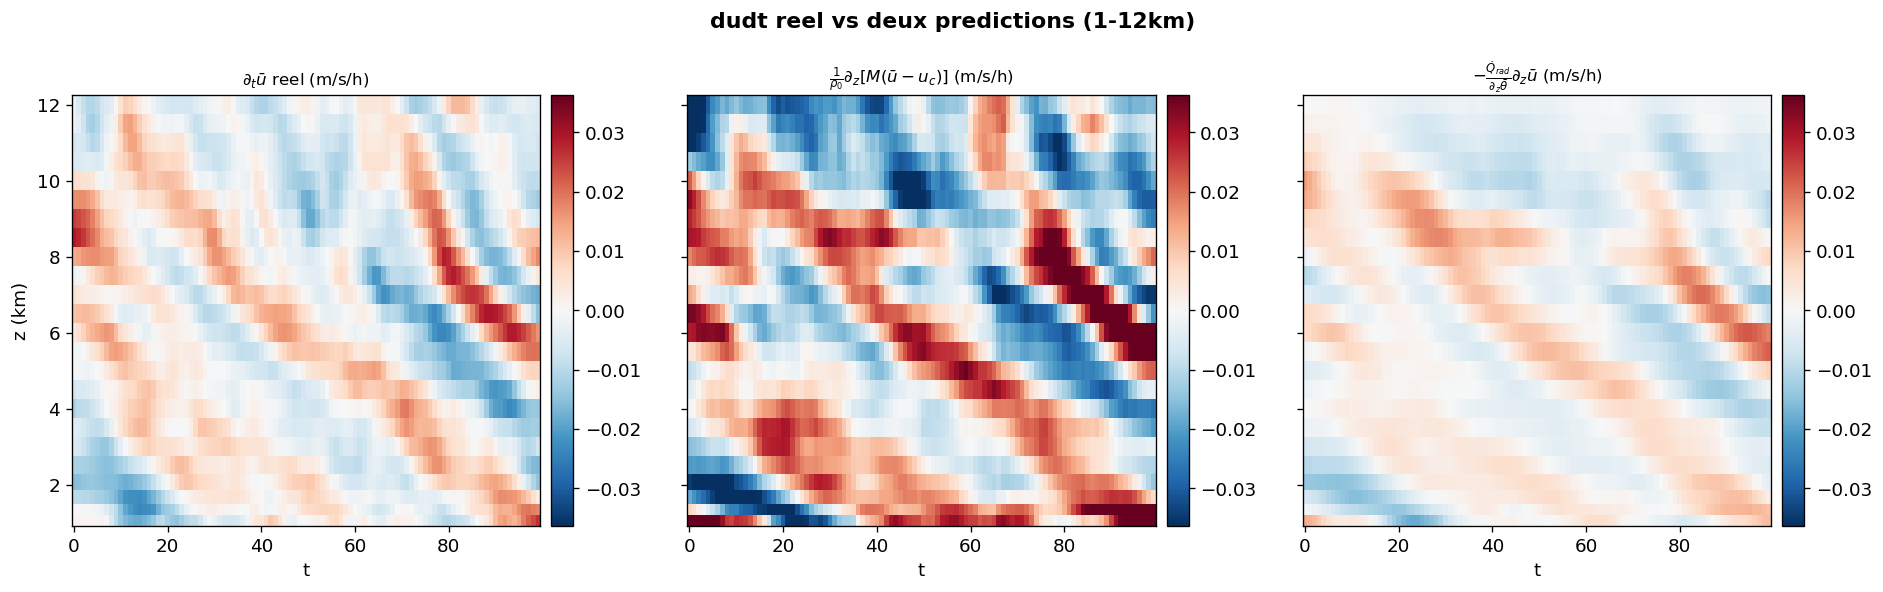

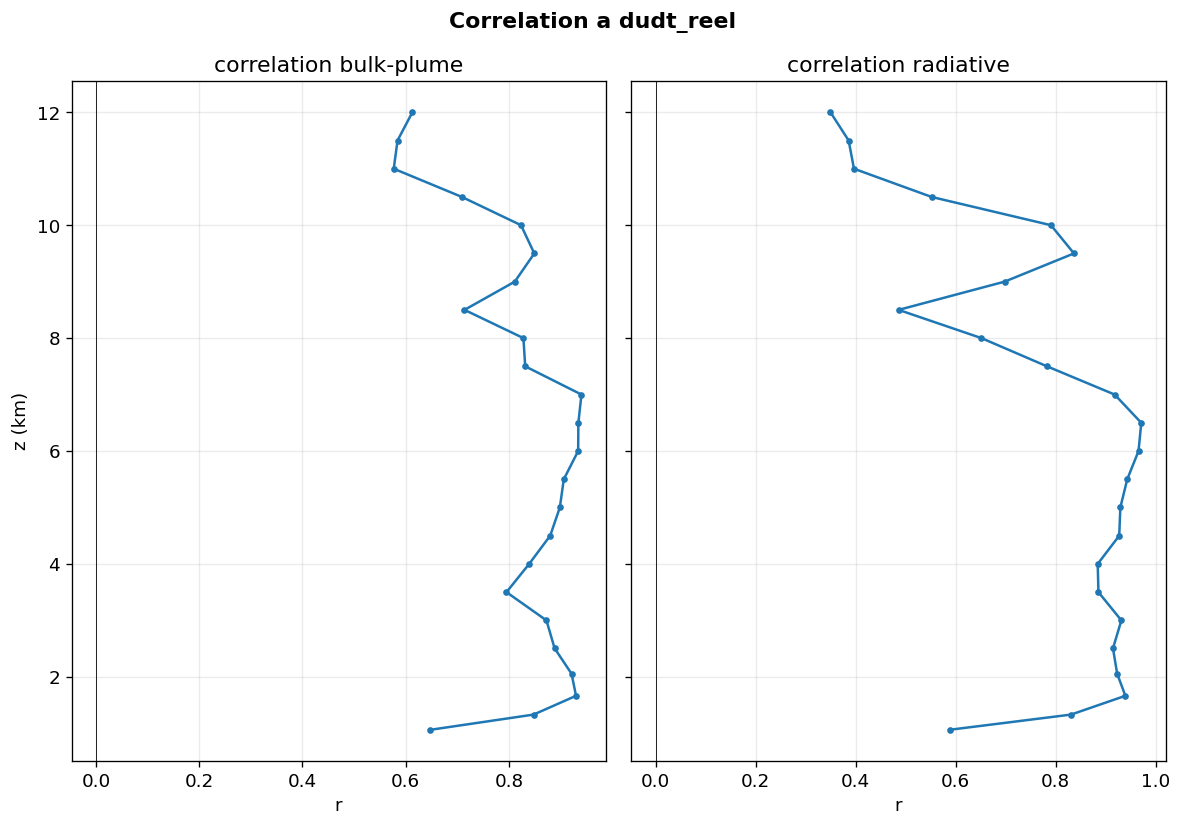

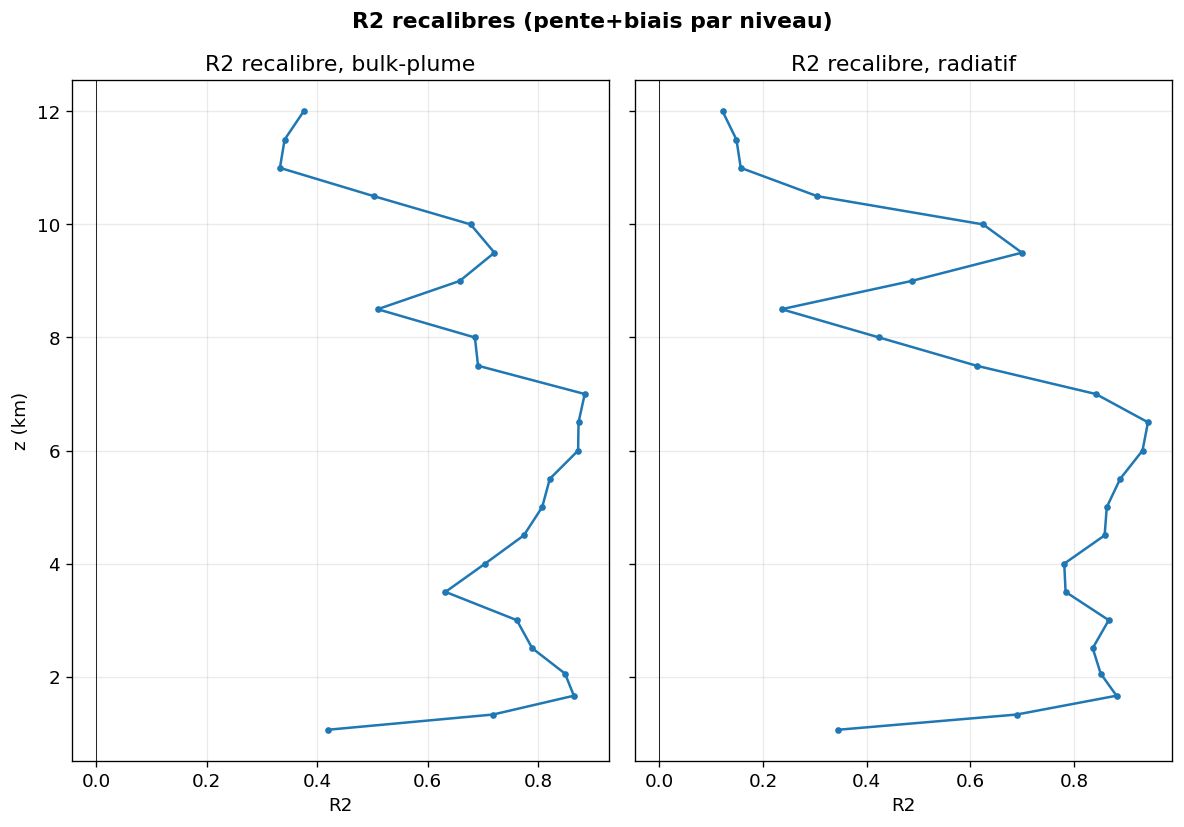

R2 median bulk-plume (2-8km / 8-12km) : 0.79 / 0.51
R2 median radiatif   (2-8km / 8-12km) : 0.85 / 0.30


In [103]:
# ============================================================
#  1) Trois cartes cote a cote : dudt reel | prediction bulk-plume | prediction radiative
# ============================================================
m112 = (alt>=1000)&(alt<=12000)

# prediction radiative : w_sec = +Qrad/dtheta_dz (signe correct etabli), dudt ~ Tu ~ -w_sec*dudz
w_sec_rad = (theta_zt/T_zt) * tntr_zt / dthetadz_zt
dudt_pred_rad = smooth_t(-w_sec_rad * dudz_tot)

fig, axes = plt.subplots(1,3,figsize=(16,5),sharey=True)
v = max(np.nanpercentile(np.abs(dudt_reel[m112]),95),
        np.nanpercentile(np.abs(dudt_pred_s[m112]),95),
        np.nanpercentile(np.abs(dudt_pred_rad[m112]),95))*3600+1e-12
for ax,(fld,lab) in zip(axes,[(dudt_reel*3600, r"$\partial_t\bar u$ reel (m/s/h)"),
                                (dudt_pred_s*3600, r"$\frac{1}{\rho_0}\partial_z[M(\bar u-u_c)]$ (m/s/h)"),
                                (dudt_pred_rad*3600, r"$-\frac{\dot Q_{rad}}{\partial_z\bar\theta}\partial_z\bar u$ (m/s/h)")]):
    im=ax.pcolormesh(tt+t_stat, zkm[m112], fld[m112], cmap='RdBu_r',
                      norm=TwoSlopeNorm(0,-v,v), shading='auto')
    ax.set_xlabel('t'); ax.set_title(lab,fontsize=10)
    fig.colorbar(im,ax=ax,pad=.02)
axes[0].set_ylabel('z (km)')
plt.suptitle("dudt reel vs deux predictions (1-12km)", fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
#  2) Correlation a dudt_reel, cote a cote, par niveau
# ============================================================
corr_bulk = np.full(n_z, np.nan); corr_rad = np.full(n_z, np.nan)
for iz in range(n_z):
    if not m112[iz]: continue
    a = dudt_reel[iz,:]
    for pred, store in [(dudt_pred_s[iz,:], 'bulk'), (dudt_pred_rad[iz,:], 'rad')]:
        ok = np.isfinite(a) & np.isfinite(pred)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15 or np.std(pred[ok]) < 1e-15: continue
        r = np.corrcoef(a[ok], pred[ok])[0,1]
        if store == 'bulk': corr_bulk[iz] = r
        else: corr_rad[iz] = r

fig, axes = plt.subplots(1,2,figsize=(10,7),sharey=True)
axes[0].plot(corr_bulk[m112], zkm[m112], 'o-', ms=3); axes[0].axvline(0,color='k',lw=.5)
axes[0].set_title('correlation bulk-plume'); axes[0].set_xlabel('r'); axes[0].set_ylabel('z (km)')
axes[1].plot(corr_rad[m112], zkm[m112], 'o-', ms=3); axes[1].axvline(0,color='k',lw=.5)
axes[1].set_title('correlation radiative'); axes[1].set_xlabel('r')
plt.suptitle("Correlation a dudt_reel", fontweight='bold')
plt.tight_layout(); plt.show()

# ============================================================
#  3) R2 recalibres (pente+biais par niveau), cote a cote
# ============================================================
def r2_recalibre(pred):
    pente = np.full(n_z, np.nan); biais = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not m112[iz]: continue
        a, b = dudt_reel[iz,:], pred[iz,:]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(b[ok]) < 1e-15: continue
        A = np.vstack([b[ok], np.ones(ok.sum())]).T
        coefs, *_ = np.linalg.lstsq(A, a[ok], rcond=None)
        pente[iz], biais[iz] = coefs
    pred_cal = pente[:,None]*pred + biais[:,None]
    r2 = np.full(n_z, np.nan)
    for iz in range(n_z):
        if not m112[iz]: continue
        a, b = dudt_reel[iz,:], pred_cal[iz,:]
        ok = np.isfinite(a) & np.isfinite(b)
        if ok.sum() < 20 or np.std(a[ok]) < 1e-15: continue
        ss_res = np.sum((a[ok]-b[ok])**2); ss_tot = np.sum((a[ok]-a[ok].mean())**2)
        r2[iz] = 1-ss_res/ss_tot if ss_tot>0 else np.nan
    return r2

R2_bulk_cal = r2_recalibre(dudt_pred_s)
R2_rad_cal = r2_recalibre(dudt_pred_rad)

fig, axes = plt.subplots(1,2,figsize=(10,7),sharey=True)
axes[0].plot(R2_bulk_cal[m112], zkm[m112], 'o-', ms=3); axes[0].axvline(0,color='k',lw=.5)
axes[0].set_title('R2 recalibre, bulk-plume'); axes[0].set_xlabel('R2'); axes[0].set_ylabel('z (km)')
axes[1].plot(R2_rad_cal[m112], zkm[m112], 'o-', ms=3); axes[1].axvline(0,color='k',lw=.5)
axes[1].set_title('R2 recalibre, radiatif'); axes[1].set_xlabel('R2')
plt.suptitle("R2 recalibres (pente+biais par niveau)", fontweight='bold')
plt.tight_layout(); plt.show()

print(f"R2 median bulk-plume (2-8km / 8-12km) : {np.nanmedian(R2_bulk_cal[m28]):.2f} / {np.nanmedian(R2_bulk_cal[(alt>=8000)&(alt<=12000)]):.2f}")
print(f"R2 median radiatif   (2-8km / 8-12km) : {np.nanmedian(R2_rad_cal[m28]):.2f} / {np.nanmedian(R2_rad_cal[(alt>=8000)&(alt<=12000)]):.2f}")